# Diferential Expression (DE)

In [1]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
library(scran)
library('glmGamPoi')
library(clusterProfiler)
library(EnhancedVolcano)
library("enrichplot")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()


In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
reference_cells <- read.csv("output/reference_cell_strict.csv") %>% dplyr::select(experiment,cell)

In [4]:
reference_cells_k6_8 <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell)

In [5]:
head(reference_cells_k6_8)

,experiment,cell
,<chr>,<chr>
1,K6,AAACCTGAGACCGGAT
2,K6,AAACCTGAGGATGCGT
3,K6,AAACCTGAGGGTTTCT
4,K6,AAACCTGCAAGGCTCC
5,K6,AAACCTGCAATCCAAC
6,K6,AAACCTGCACGGTGTC


In [6]:
reference_cells_k6_8 %>%
  summarise(total_unique_cells = n_distinct(cell, experiment))

total_unique_cells
<int>
13763


In [6]:
# # seurat object (we are going to use the. non normalize counts)
 FL.integrated <- readRDS("output/FL_CLL_integrated_clean.rds")

In [7]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_complete.csv") %>% mutate(experiment=str_extract(subject, "^.{2}")) %>%
         mutate(cell_seurat=case_when(experiment == "K1" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [8]:
cells1 <- cells1 %>% filter(batch %in% c("K6", "K7","K8"))
str(cells1)

'data.frame':	305 obs. of  2 variables:
 $ cell_seurat: chr  "CTGAAGTAGTTTAGGA-1_6" "ACTGAGTTCTACTTAC-1_6" "GACCAATTCAGCATGT-1_6" "ACGATACAGGAGCGAG-1_6" ...
 $ batch      : chr  "K6" "K6" "K6" "K6" ...


In [55]:

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- reference_cells_k6_8 %>% mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [58]:
cells1 %>% str()
cells2 %>% pull(cell_seurat) %>% unique() %>% str()

'data.frame':	305 obs. of  2 variables:
 $ cell_seurat: chr  "CTGAAGTAGTTTAGGA-1_6" "ACTGAGTTCTACTTAC-1_6" "GACCAATTCAGCATGT-1_6" "ACGATACAGGAGCGAG-1_6" ...
 $ batch      : chr  "K6" "K6" "K6" "K6" ...
 chr [1:13458] "AAACCTGAGACCGGAT-1_6" "AAACCTGAGGATGCGT-1_6" ...


**The package DESeq2 provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions.**
- **Why un-normalized counts?**
As input, the DESeq2 package expects count data as obtained, e.g., from RNA-seq or another high-throughput sequencing experiment, in the form of a matrix of integer values. The value in the i-th row and the j-th column of the matrix tells how many reads can be assigned to gene i in sample j. Analogously, for other types of assays, the rows of the matrix might correspond e.g. to binding regions (with ChIP-Seq) or peptide sequences (with quantitative mass spectrometry). We will list method for obtaining count matrices in sections below.
The values in the matrix should be un-normalized counts or estimated counts of sequencing reads (for single-end RNA-seq) or fragments (for paired-end RNA-seq). The RNA-seq workflow describes multiple techniques for preparing such count matrices. It is important to provide count matrices as input for DESeq2’s statistical model (Love, Huber, and Anders 2014) to hold, as only the count values allow assessing the measurement precision correctly. The DESeq2 model internally corrects for library size, so transformed or normalized values such as counts scaled by library size should not be used as input.

### remove low expression

In [59]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
      
    # Remove lowly expressed genes (genes expressed in <10% of cells)
    expressed_genes <- rowSums(cts[, -1] > 0) / ncol(cts[, -1]) > 0.05
    cts <- cts[expressed_genes, ]
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
       filter( 
               !geneName %like% "^RPL",
               !geneName %like% "^RPS",
               !geneName %like% "^IG[HKL][LVMCGEA]") %>%
      #         #!geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    #estimate data dispersions
#    dds <- estimateDispersions(dds)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced=~batch, #If the full design contained other variables, such as a batch variable, e.g. ~batch + condition then the likelihood ratio test would look like:
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k6_8 <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



In [60]:
#saveRDS(dds_k6_8, "output/DE_k6-K8.rds")

In [29]:
dds_k6_8 <- readRDS("output/DE_k6-K8.rds")

In [30]:
summary(results(dds_k6_8, alpha = 0.05))


out of 8535 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 259, 3%
LFC < 0 (down)     : 284, 3.3%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [8]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds_k6_8) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.19500049,-0.135863349,NA,0.835725191,0.36063814,0.7133878
ISG15,0.14244756,0.007659256,NA,0.001919161,0.96505790,0.9922623
SDF4,0.25377401,0.106120355,NA,0.643530624,0.42244895,0.7530643
B3GALT6,0.06711607,-0.118381987,NA,0.195282720,0.65856264,0.8817090
UBE2J2,0.20841410,0.299308125,NA,5.128403051,0.02355275,0.1837502
INTS11,0.27524975,0.103262317,NA,0.737979052,0.39032389,0.7350870


In [15]:
#DE_scSHM %>% filter(rowname %in% c("MCM5","MCM6", "MCM7", "ORC1","ORC2", "ORC6", "CDC6","CDK2","CCNE1")) #Cell Cycle Score" Tirosh et al. (2015

In [63]:
#write.csv( as.data.frame(DE_scSHM), file="output/DE_results_k6-8.csv", row.names=FALSE )

In [2]:
DE_scSHM <- read.csv("output/DE_results_k6-8.csv" )

In [3]:
head(DE_scSHM)

,rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
1,NOC2L,0.19500049,-0.135863349,NA,0.835725191,0.36063814,0.7133878
2,ISG15,0.14244756,0.007659256,NA,0.001919161,0.96505790,0.9922623
3,SDF4,0.25377401,0.106120355,NA,0.643530624,0.42244895,0.7530643
4,B3GALT6,0.06711607,-0.118381987,NA,0.195282720,0.65856264,0.8817090
5,UBE2J2,0.20841410,0.299308125,NA,5.128403051,0.02355275,0.1837502
6,INTS11,0.27524975,0.103262317,NA,0.737979052,0.39032389,0.7350870


In [65]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
   #           mutate(threshold = padj < 0.05 & abs(log2FoldChange) >= 0.58) %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj )) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

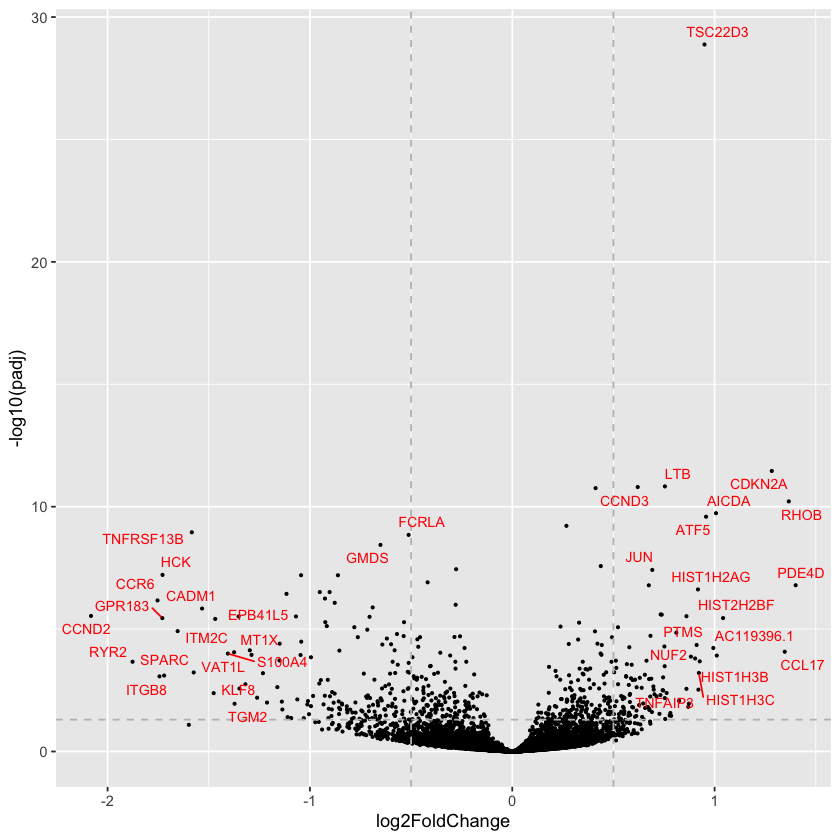

In [66]:
td <- VolcanoPlot(DE_scSHM)
td

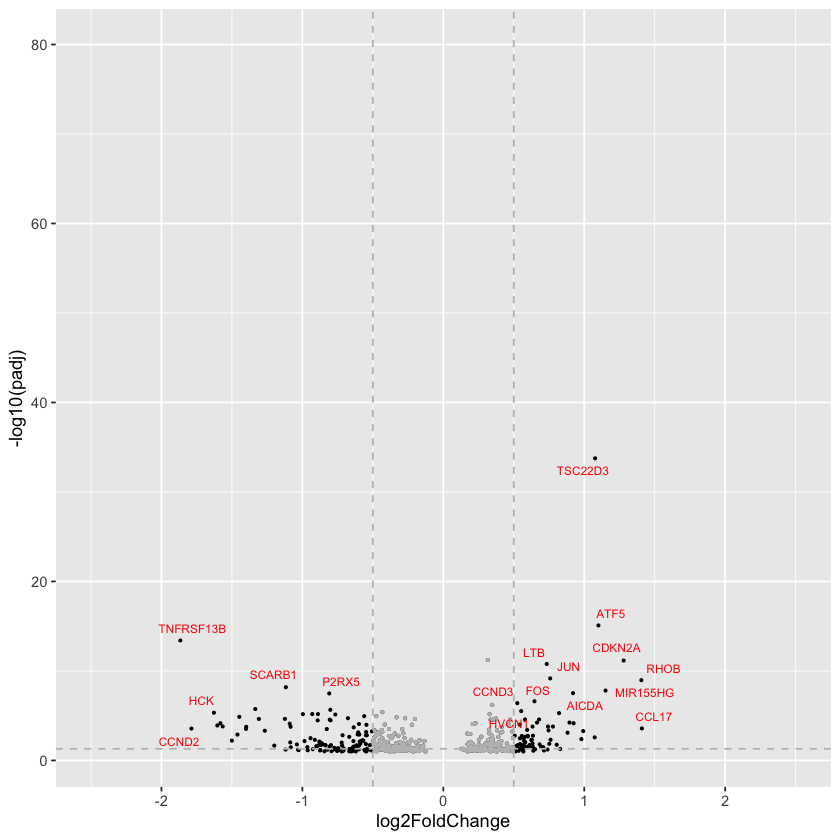

In [16]:
tc <- VolcanoPlotFixedFrame(DE_scSHM)
tc

In [67]:
fig_save(td , filename = ("figs_paper/volcano_plot_k7_8"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

If within a row, all samples have zero counts, the baseMean column will be zero, and the log2 fold change estimates, p value and adjusted p value will all be set to NA.
If a row contains a sample with an extreme count outlier then the p value and adjusted p value will be set to NA. These outlier counts are detected by Cook’s distance. Customization of this outlier filtering and description of functionality for replacement of outlier counts and refitting is described below
If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p value will be set to NA. Description and customization of independent filtering is described below

## Volcano plot lindo

### List of DNA repair genes

In [4]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [5]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [6]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
AICDA,0.2175757,1.007083,NA,54.66464,1.511475e-13,1.84292e-10


In [12]:
# Define general significance cutoffs
log2FC_threshold <- 0.25
pval_threshold <- 0.05

# Assign categories to the genes
DE_scSHM <- DE_scSHM %>%
  mutate(category = case_when(
    log2FoldChange > log2FC_threshold & padj < pval_threshold ~ "Upregulated",
    log2FoldChange < -log2FC_threshold & padj < pval_threshold ~ "Downregulated",
    TRUE ~ "Not significant"
  ))


In [13]:
# Define genes to highlight
genes_volcano <- DE_scSHM %>% filter(category %in% c("Upregulated", "Downregulated")) 
filtered_genes <- genes_volcano[genes_volcano$rowname %in% genes_names$gene, ]

In [14]:
ev <- EnhancedVolcano(DE_scSHM,lab = DE_scSHM$rowname, x = "log2FoldChange",y = "padj",
                       pCutoff = pval_threshold ,
                       FCcutoff = 0.25,
                            border = "full",
        selectLab = filtered_genes,    #DE_scSHM$rowname[which(names(keyvals) %in% c("Upregulated", "Downregulated"))],
        borderWidth = 0.8,borderColour = "black",
        labSize = 4,
#        boxedLabels = TRUE,
        gridlines.major = FALSE,
        gridlines.minor = FALSE,
#        boxedLabels = TRUE,
 #       cutoffLineType = NULL,
        cutoffLineCol = "grey",
        col = c("#a6cee3","#1f78b4" ,"#b2df8a" ,"#33a02c"),
        title= NULL,
        subtitle=NULL,
        colCustom = keyvals,
        caption = NULL,
        ylab = bquote(~-Log[10] ~ padjust)) #+
# geom_text_repel(
#   data = DE_scSHM %>% filter(rowname %in% filtered_genes),
#   aes(x = log2FoldChange, y = -log10(padj), label = rowname),
#   size = 4,
#   max.overlaps = Inf
# )


ev

ERROR: Error in EnhancedVolcano(DE_scSHM, lab = DE_scSHM$rowname, x = "log2FoldChange", : object 'keyvals' not found


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


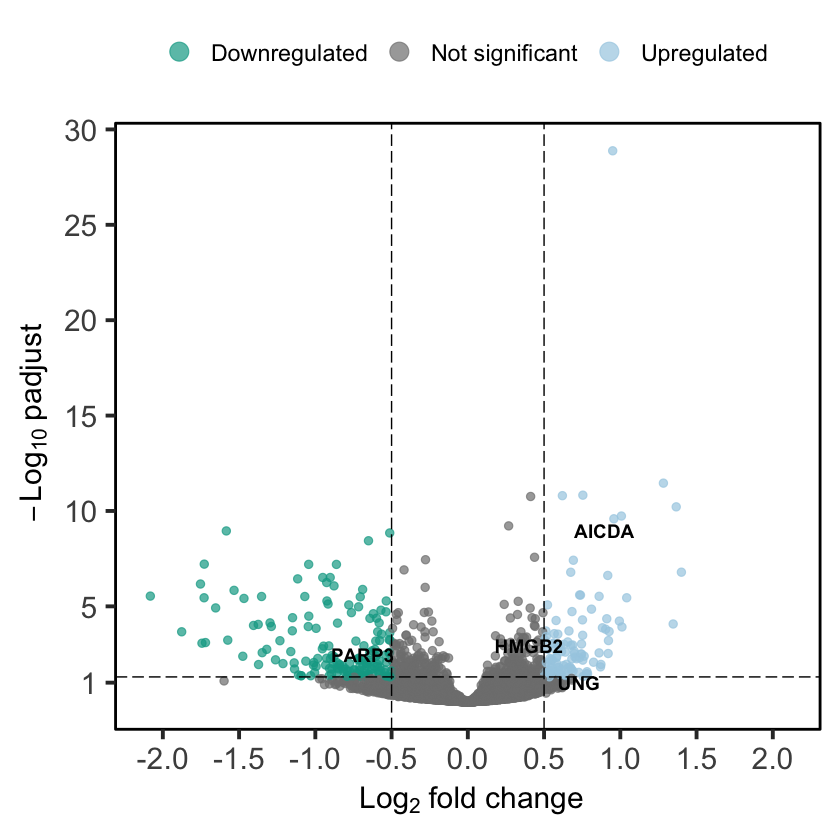

In [31]:
# Define general significance cutoffs
log2FC_threshold <- 0.5
pval_threshold <- 0.05

# Assign categories to the genes
DE_scSHM <- DE_scSHM %>%
  mutate(category = case_when(
    log2FoldChange > log2FC_threshold & padj < pval_threshold ~ "Upregulated",
    log2FoldChange < -log2FC_threshold & padj < pval_threshold ~ "Downregulated",
    TRUE ~ "Not significant"
  ))

# Define genes to highlight
genes_volcano <- DE_scSHM %>% filter(category %in% c("Upregulated", "Downregulated")) 
filtered_genes <- genes_volcano[genes_volcano$rowname %in% genes_names$gene, ]

# Create a color mapping for all genes based on their category
keyvals <- 
           ifelse(DE_scSHM$category == "Upregulated", "#a6cee3",  # Blue for upregulated
           ifelse(DE_scSHM$category == "Downregulated", "#00A693",  # Green for downregulated
           "gray50"))  # Gray for non-significant genes

# Set category names for legend (excluding non-significant genes)
names(keyvals) <- 
                  ifelse(DE_scSHM$category == "Upregulated", "Upregulated",
                  ifelse(DE_scSHM$category == "Downregulated", "Downregulated",
                  "Not significant"))

# Remove non-significant genes from legend
keyvals[which(names(keyvals) == "Not significant")] <- NA

# Create EnhancedVolcano plot
ev <- EnhancedVolcano(DE_scSHM, 
                      lab = DE_scSHM$rowname, 
                      selectLab = filtered_genes,
                      x = "log2FoldChange", 
                      y = "padj",
                      pCutoff = pval_threshold, 
                      FCcutoff = log2FC_threshold,
                      colCustom = keyvals,  # Apply color scheme
                      colAlpha = 0.7,  # Adjust transparency
                      border = "full",
                      borderWidth = 0.8,
                      borderColour = "black",
                      labSize = 4,
                      gridlines.major = FALSE,
                      gridlines.minor = FALSE,
                      title = NULL,
                      subtitle = NULL,
                      caption = NULL,
                      ylab = bquote(~-Log[10] ~ padjust)) +
  
# Add highlighted gene labels with bold font and red color
geom_text_repel(
  data = DE_scSHM %>% filter(rowname %in% filtered_genes$rowname),  # Filter using the correct rownames
  aes(x = log2FoldChange, y = -log10(padj), label = rowname),
  size = 4, 
  color = "black",  # Change label color
  fontface = "bold",  # Make it bold
  max.overlaps = Inf
) +

  # Adjust the x-axis range from -2.2 to 2.1
  scale_x_continuous(limits = c(-2.1, 2.1),
                    breaks = c(-0.5,-1,-1.5,-2,0,0.5,1,1.5,2)) + # More detailed breaks) +

  scale_y_continuous(
    breaks = c(1, 5, 10, 15, 20, 25,30),  # More detailed breaks
    labels = c( "1", "5", "10","15", "20", "25", "30")
  ) 
  

# Display the plot
ev


In [36]:
fig_save(ev , filename = ("figs_paper/volcano_plot_2025"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

# Pathway analysis

### Convert genes names to Entrez Gene

In [19]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [20]:
## Remove any NA values (reduces the data by quite a bit)
DE_scSHM <- dplyr::filter(DE_scSHM, entrez != "NA")

## Remove any Entrez duplicates
DE_scSHM <- DE_scSHM[which(duplicated(DE_scSHM$entrez) == F), ]

In [78]:
ber_genes <- genes_names %>% filter(pathway == "BER")

In [123]:
DE_scSHM %>% filter(padj < 0.05, log2FoldChange > 0.6)  %>% arrange(padj,log2FoldChange) #padj < 0.05

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
TSC22D3,2.16552735,0.9500241,NA,146.425599,1.546641e-33,1.320058e-29,1831,TSC22 domain family member 3
CDKN2A,0.13929665,1.2825818,NA,64.990304,8.139674e-16,3.473606e-12,1029,cyclin dependent kinase inhibitor 2A
LTB,5.53447163,0.7543405,NA,61.315244,5.214667e-15,1.483573e-11,4050,lymphotoxin beta
CCND3,0.89694449,0.6200648,NA,60.625074,7.392835e-15,1.577446e-11,896,cyclin D3
RHOB,0.15096636,1.3666296,NA,57.156680,4.276741e-14,6.083664e-11,388,ras homolog family member B
AICDA,0.21757572,1.0070825,NA,54.664637,1.511475e-13,1.842920e-10,57379,activation induced cytidine deaminase
ATF5,0.52562074,0.9578431,NA,53.746487,2.407338e-13,2.568329e-10,22809,activating transcription factor 5
JUN,1.65693575,0.6920869,NA,42.664006,6.726500e-11,3.827378e-08,3725,"Jun proto-oncogene, AP-1 transcription factor subunit"
PDE4D,0.10090261,1.4005561,NA,39.275378,3.789502e-10,1.617170e-07,5144,phosphodiesterase 4D


In [40]:
DE_scSHM %>% filter(rowname == "MSH3")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,category,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
MSH3,0.1007603,0.2994237,NA,2.471663,0.1159381,0.4346923,Not significant,4437,mutS homolog 3


## 1) Generally Applicable Gene-set Enrichment for Pathway Analysis: gage

In [12]:
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]

In [42]:
# # pathways not related with B cells
# unvaluable_pathway <- c("hsa04966 Collecting duct acid secretion","hsa04971 Gastric acid secretion","hsa04914 Progesterone-mediated oocyte maturation",
#                         "hsa04720 Long-term potentiation","hsa04916 Melanogenesis", "hsa04260 Cardiac muscle contraction",
#                        "hsa04270 Vascular smooth muscle contraction","hsa04114 Oocyte meiosis","hsa04972 Pancreatic secretion","hsa04730 Long-term depression")

In [43]:
#remove those pathways from the list genes
#kegg.sets.hs_filter <- discard(kegg.sets.hs, (names(kegg.sets.hs) %in% unvaluable_pathway ))

In [23]:
## Extract the foldchanges
foldchanges = DE_scSHM$log2FoldChange

## Name each fold change with the corresponding Entrez ID
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

26155         9636        51150       126792       118424        54973 
-0.135863349  0.007659256  0.106120355 -0.118381987  0.299308125  0.103262317

In [24]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [25]:
#saveRDS(foldchanges, file = "foldchanges_v2.rds")

In [69]:
pathway_id <- "hsa03430 Mismatch repair"  # Replace with the pathway you want
genes_in_pathway <- kegg.sets.hs[[pathway_id]]
genes_in_pathway  # This will show the gene IDs in that pathway

[1] "10714" "27030" "2956"  "29935" "3978"  "4292"  "4436"  "4437"  "5111" 
[10] "5395"  "5424"  "5425"  "57804" "5981"  "5982"  "5983"  "5984"  "5985" 
[19] "6117"  "6118"  "6119"  "6742"  "9156"

In [82]:
# Filter genes that are in the pathway
pathway_genes_df <- DE_scSHM[DE_scSHM$entrez %in% genes_in_pathway, ]

# View the results
pathway_genes_df %>% filter( padj < 0.05)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
RPA2,0.3729698,0.3067396,NA,8.976332,0.002739831,0.04514373,6118,replication protein A2


In [126]:
genes_names$gene

[1] "APEX1"  "APEX2"  "APLF"   "APTX"   "CHAF1A" "CHAF1B" "ERCC6L" "FEN1"  
 [9] "HMGB1"  "HMGB2"  "LIG1"   "LIG3"   "MBD4"   "MPG"    "MUTYH"  "NEIL1" 
[17] "NEIL2"  "NEIL3"  "NTHL1"  "NUDT1"  "OGG1"   "PARP1"  "PARP2"  "PARP3" 
[25] "PARP4"  "PCNA"   "PNKP"   "POLB"   "POLD1"  "POLD2"  "POLD4"  "POLD3" 
[33] "POLE"   "POLE2"  "POLE3"  "POLE4"  "POLL"   "POLQ"   "RECQL"  "SMUG1" 
[41] "TDG"    "UNG"    "XRCC1"  "RPA1"   "EXO1"   "MLH1"   "MLH3"   "MSH2"  
[49] "MSH3"   "MSH4"   "MSH5"   "MSH6"   "PMS1"   "PMS2"   "PMS2L3" "RFC1"  
[57] "RFC2"   "RFC3"   "RFC4"   "RFC5"   "RPA2"   "RPA3"   "RPA4"   "ADAR"  
[65] "AICDA"  "FAM72A"

In [125]:
DE_scSHM %>% filter(rowname %in% genes_names$gene, padj < 0.05, log2FoldChange > 0.5)  %>% arrange(padj,log2FoldChange) #padj < 0.05

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.2175757,1.0070825,NA,54.66464,1.511475e-13,1.842920e-10,57379,activation induced cytidine deaminase
HMGB2,1.7863649,0.5121202,NA,22.43586,2.194334e-06,1.950900e-04,3148,high mobility group box 2
UNG,0.1314172,0.5507903,NA,11.55098,6.790426e-04,1.660639e-02,7374,uracil DNA glycosylase


In [50]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs, same.dir=TRUE,use.fold=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,12)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa03030 DNA replication,0.0003230880,3.613268,0.0003230880,0.04297071,32,0.0003230880
hsa04110 Cell cycle,0.0008884539,3.171881,0.0008884539,0.05908218,98,0.0008884539
hsa04114 Oocyte meiosis,0.0015854669,3.003513,0.0015854669,0.07028903,74,0.0015854669
hsa03430 Mismatch repair,0.0053743383,2.697891,0.0053743383,0.17869675,21,0.0053743383
hsa03440 Homologous recombination,0.0089277734,2.477445,0.0089277734,0.23747877,21,0.0089277734
hsa03040 Spliceosome,0.0112731496,2.302002,0.0112731496,0.24988815,122,0.0112731496
hsa00240 Pyrimidine metabolism,0.0266075325,1.949376,0.0266075325,0.45838422,73,0.0266075325
hsa04914 Progesterone-mediated oocyte maturation,0.0318902103,1.873738,0.0318902103,0.45838422,54,0.0318902103
hsa03050 Proteasome,0.0355142813,1.840310,0.0355142813,0.45838422,42,0.0355142813
"hsa00260 Glycine, serine and threonine metabolism",0.0389332407,1.862820,0.0389332407,0.45838422,11,0.0389332407


In [27]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

[1] "hsa03030 DNA replication"          "hsa04110 Cell cycle"              
[3] "hsa04114 Oocyte meiosis"           "hsa03430 Mismatch repair"         
[5] "hsa03440 Homologous recombination"

In [28]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

[1] "hsa03030" "hsa04110" "hsa04114" "hsa03430" "hsa03440"

In [84]:
# Perform gage analysis (assuming foldchanges and kegg.sets.hs are already defined)
keggres <- gage(foldchanges, gsets = kegg.sets.hs, same.dir = TRUE)

# Extract the "greater" (up-regulated) and "less" (down-regulated) matrices
greater_data <- keggres$greater
less_data <- keggres$less

# Convert matrices to data frames for easier handling
greater_df <- data.frame(
  pathway = rownames(greater_data),  # Pathway names (rownames of the matrix)
  p_value = greater_data[, "p.val"],  # Access p-value column by name
  stat_mean = greater_data[, "stat.mean"],  # Access mean stat column by name
  set_size = greater_data[, "set.size"],  # Access set size column by name
  regulation = "Upregulated",  # Label for upregulated
  stringsAsFactors = FALSE
)

less_df <- data.frame(
  pathway = rownames(less_data),  # Pathway names (rownames of the matrix)
  p_value = less_data[, "p.val"],  # Access p-value column by name
  stat_mean = less_data[, "stat.mean"],  # Access mean stat column by name
  set_size = less_data[, "set.size"],  # Access set size column by name
  regulation = "Downregulated",  # Label for downregulated
  stringsAsFactors = FALSE
)

# Subset to top 6 hits (based on smallest p-value)
top_greater_df <- greater_df[order(greater_df$p_value), ][1:6, ]
top_less_df <- less_df[order(less_df$p_value), ][1:6, ]

# Combine the data frames for top 6 hits
combined_df <- rbind(top_greater_df, top_less_df)


# Reorder the pathways based on stat_mean
combined_df <- combined_df %>%
  mutate(pathway = reorder(pathway, stat_mean),
         regulation = factor(regulation, levels = c("Upregulated", "Downregulated")))  # Order regulation

# Create the plot
plot <- ggplot(combined_df, aes(x = stat_mean, y = pathway, color = -log10(p_value), size = set_size)) +
  geom_point(alpha = 0.7) +  # Create points with transparency
  scale_color_gradient(low = "darkblue", high = "mediumseagreen") +  # Custom greenish-bluish gradient
  scale_size_continuous(range = c(3, 10)) +  # Adjust the size range of the dots
  facet_wrap(~regulation, scales = "free_y", ncol = 1) +  # Separate upregulated and downregulated
  labs(x = "Mean Stat", y = "Pathway", title = "Dotplot of Top 6 Upregulated and Downregulated Pathways") +
  theme_minimal(base_size = 14) +  # Set base font size
  theme(
    legend.position = "bottom",  # Position the legend at the bottom
    strip.text = element_text(size = 14),  # Increase facet label size
    axis.text = element_text(size = 12),  # Increase axis text size
    axis.title = element_text(size = 14),  # Increase axis title size
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),  # Increase plot title size and make it bold
    panel.grid.major = element_blank(),  # Remove major grid lines
    panel.grid.minor = element_blank()   # Remove minor grid lines
  )

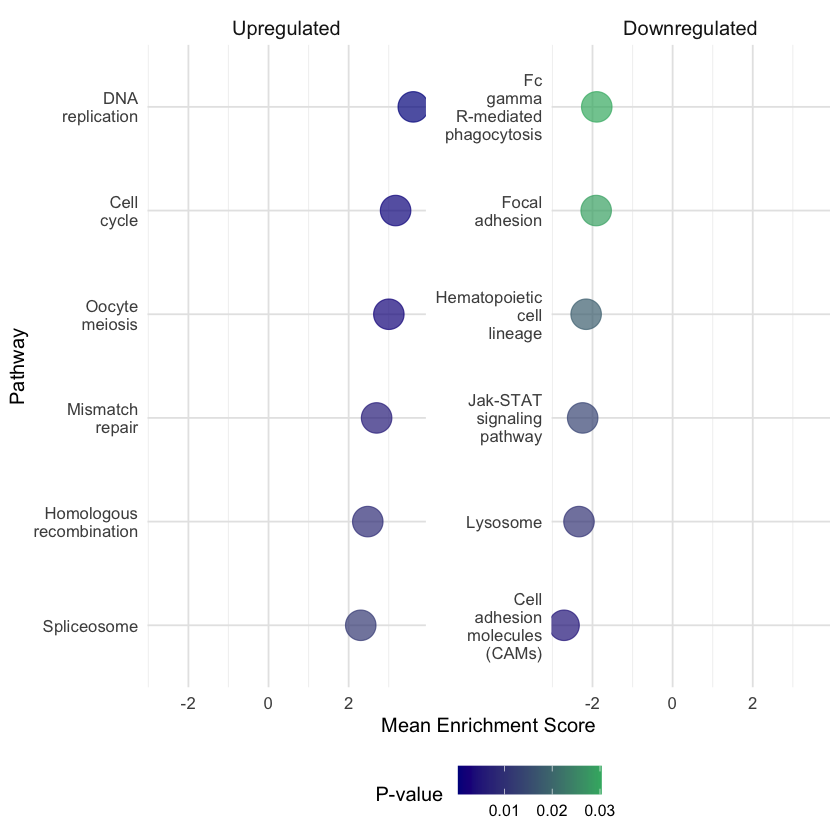

In [89]:

# Remove "hsaXXX" from the pathway names
combined_df <- combined_df %>%
  mutate(pathway = gsub("hsa[0-9]+ ", "", pathway))  # Remove "hsa" prefix and ID numbers

# Add a newline character to the pathway names at desired positions
combined_df <- combined_df %>%
  mutate(pathway = gsub(" ", "\n", pathway))  # This adds a line break after each space in the pathway name


# Reorder the pathways based on stat_mean
combined_df <- combined_df %>%
  mutate(pathway = reorder(pathway, stat_mean),
         regulation = factor(regulation, levels = c("Upregulated", "Downregulated")))  # Order regulation

# Create the plot
plot <- ggplot(combined_df, aes(x = stat_mean, y = pathway, color = p_value,size=5)) + #size = set_size
  geom_point(alpha = 0.7) +  # Create points with transparency
  scale_color_gradient(low = "darkblue", high = "mediumseagreen", name = "P-value") +  # Custom greenish-bluish gradient for p-value
  scale_size_continuous(range = c(4, 10),name = "Set Size") +  # Adjust the size range of the dots
  facet_wrap(~regulation, scales = "free_y", ncol = 2) +  # Separate upregulated and downregulated
  labs(x = "Mean Enrichment Score", y = "Pathway") +  # Remove the title
  theme_minimal(base_size = 12) +  # Set base font size
  theme(
    legend.position = "bottom",  # Position the legend inside the plot area (right side)
    strip.text = element_text(size = 12),  # Increase facet label size
    axis.text = element_text(size = 10),  # Increase axis text size
    axis.title = element_text(size = 12),  # Increase axis title size
    plot.title = element_blank(),  # Remove plot title
    panel.grid.major = element_line(color = "gray90", size = 0.5),  # Softer grid lines (light gray)
    panel.grid.minor = element_line(color = "gray95", size = 0.3)   # Softer minor grid lines
  ) +
  guides(size = "none")  # Remove the size legend
plot

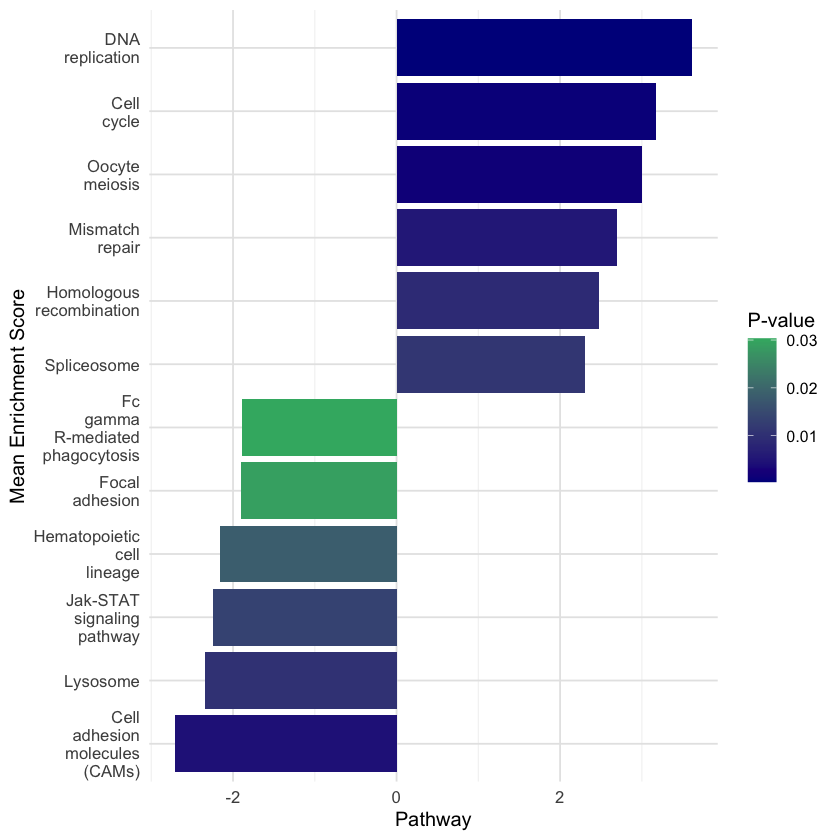

In [111]:
# Create the plot
plot <- ggplot(combined_df, aes(x = reorder(pathway, stat_mean), y = stat_mean, fill = p_value)) +
  geom_bar(stat = "identity") + # Create points with transparency
  coord_flip() +
  scale_fill_gradient(low = "darkblue", high = "mediumseagreen", name = "P-value") +  # Custom greenish-bluish gradient for p-value
  scale_size_continuous(range = c(4, 10),name = "Set Size") +  # Adjust the size range of the dots
#  facet_wrap(~regulation, scales = "free_y", ncol = 2) +  # Separate upregulated and downregulated
  labs(x = "Mean Enrichment Score", y = "Pathway") +  # Remove the title
  theme_minimal(base_size = 12) +  # Set base font size
  theme(
    legend.position = "right",  # Position the legend inside the plot area (right side)
    strip.text = element_text(size = 12),  # Increase facet label size
    axis.text = element_text(size = 10),  # Increase axis text size
    axis.title = element_text(size = 12),  # Increase axis title size
    plot.title = element_blank(),  # Remove plot title
    panel.grid.major = element_line(color = "gray90", size = 0.5),  # Softer grid lines (light gray)
    panel.grid.minor = element_line(color = "gray95", size = 0.3)   # Softer minor grid lines
  ) +
  guides(size = "none")  # Remove the size legend
plot

In [116]:
# Save the plot for publication
ggsave("figs_paper/dotplot_pathways_2025.pdf", plot, width = 18, height = 15, units = "cm", dpi = 320)
ggsave("figs_paper/dotplot_pathways_2025.png", plot, width = 18, height = 15, units = "cm", dpi = 320)


## 3) KEGG Enrichment Analysis of a gene set : Cluster profiler tool

In [262]:
kegg_organism = "hsa"
kk2 = gseKEGG(geneList     = foldchanges,
               organism     = kegg_organism,
               minGSSize    = 3,
               maxGSSize    = 800,
               pvalueCutoff = 1,
               pAdjustMethod = "none",
               keyType       = "ncbi-geneid")

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



In [261]:
kk2@result %>% filter(p.adjust <= 0.05) %>% arrange(-enrichmentScore,-NES) %>% head(.,11) #filter(Description %in% c("Histidine metabolism"))#

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [25]:
kk2@result %>% filter(Description == "DNA replication")

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
hsa03030,hsa03030,DNA replication,32,0.6369545,2.158097,1.803864e-05,1.803864e-05,0.001348151,1553,"tags=59%, list=19%, signal=48%",4173/4175/54107/5424/6118/5422/4176/2237/5985/5982/5983/3978/23649/10714/4171/4174/5425/5557/10535


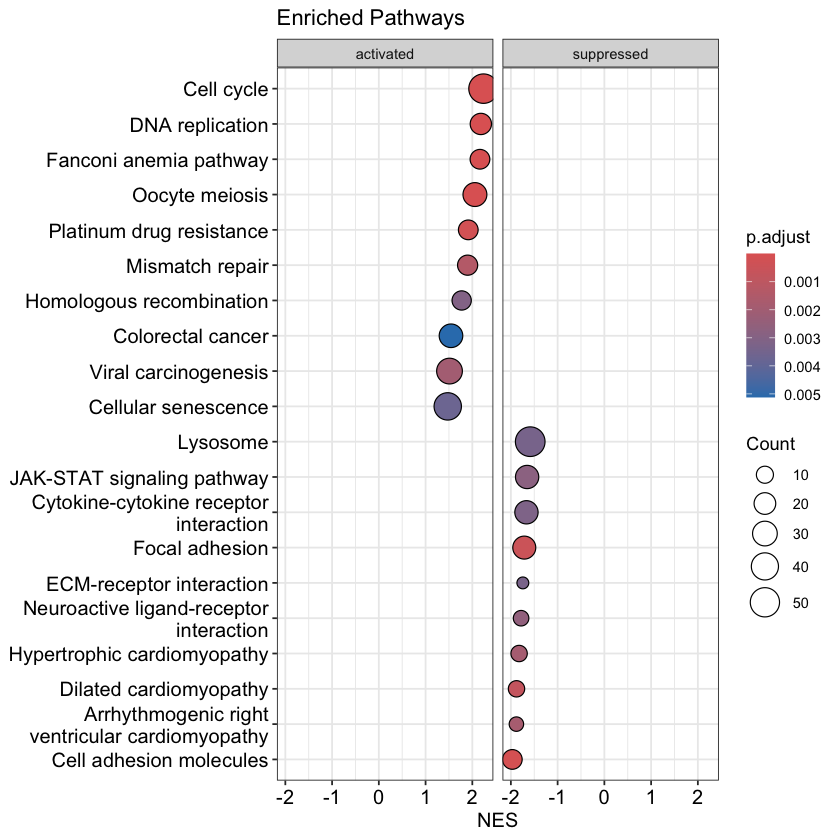

In [183]:
da <- dotplot(kk2, x= "NES",showCategory = 10, title = "Enriched Pathways" , split=".sign") + facet_grid(.~.sign)
da

#### generate a df from every pathway of interest

In [60]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")#,"VEGF signaling pathway",
# #          "Ribosome", "Antigen processing and presentation", "Cytokine-cytokine receptor interaction")

# # create an empty list to store the data frames
# df_list <- list()

# for (i in paths) {
#     i$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$i, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)
    
#     df <- DE_scSHM %>% filter(entrez %in% i$entrez)
#     # use a unique name as the index of the list
#     df_list[[paste0("df_", i)]] <- df
# }

In [61]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")

# KEGG_CELL_CYCLE$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$KEGG_CELL_CYCLE, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)

# KEGG_CELL_CYCLE$entrez

# df <- DE_scSHM %>% filter(entrez %in% KEGG_CELL_CYCLE$entrez)

In [62]:
str(path$KEGG_MAPK_SIGNALING_PATHWAY)

 chr [1:267] "JUN" "MEF2C" "ELK4" "ELK1" "JUND" "GADD45B" "MAP3K20" "STMN1" ...


In [63]:
# create an empty list to store the data frames
df_list <- list()

for (i in keggresids) {
    xc <- kk2@result %>% filter(ID == i) %>% mutate(genes = gsub("/", ",", core_enrichment)) %>% pull(genes)
    my_vector <- strsplit(xc, ",")[[1]] 
    df <- DE_scSHM %>% filter(entrez %in% my_vector)
    # use a unique name as the index of the list
    df_list[[paste0("df_", i)]] <- df
}

In [64]:
# assign each data frame to a separate variable
for (i in names(df_list)) {
  assign(i, df_list[[i]])
}

In [222]:
#set.seed(123)
x2 = pairwise_termsim(kk2)
xc <- emapplot(x2, showCategory = selected_pathways,group_category = T,group_legend = T,nCluster = 3, layaout= 'gem')
xc

ERROR: Error in emapplot_internal(x, showCategory = showCategory, ...): unused arguments (group_category = TRUE, group_legend = TRUE, layaout = "gem")


In [66]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)
set.seed(31)
x2 = pairwise_termsim(kk2)
xc <- emapplot(
    x2,
    showCategory = selected_pathways,
    cluster.params = list(
        cluster=TRUE,
        n=3,
        legend=TRUE
    ),
    layout.params = list(
        layout = "gem"
    )
)

pdf(file = paste0("figs_paper/emapplot.pdf"), 8.8, 5) 
print(xc) 
dev.off() 

pdf 
  2

In [224]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)
#set.seed(31)
x2 = pairwise_termsim(kk2)
xc <- emapplot(
    x2,
    showCategory = selected_pathways,
    cluster.params = list(
#        cluster=TRUE,
        n=3,
        legend=TRUE
    ),
    layout.params = list(
        layout = "gem"
    )
)

#pdf(file = paste0("figs_paper/emapplot.pdf"), 8.8, 5) 
print(xc) 
#dev.off()

ERROR: Error in emapplot_internal(x, showCategory = showCategory, ...): unused arguments (cluster.params = list(3, TRUE), layout.params = list("gem"))


In [265]:
selected_pathways <- c("DNA replication","Oocyte meiosis","Mismatch repair", "Cell cycle", "Homologous recombination", "Spliceosome",#neg
                       "Cell adhesion molecules","Lysosome","JAK-STAT signaling pathway",
                      "Hematopoietic cell lineage","Focal adhesion","Fc gamma R-mediated phagocytosis")

                       
                      # "Base excision repair","Fc gamma R-mediated phagocytosis","MicroRNAs in cancer","Lysosome",
                      #  "TGF-beta signaling pathway", "ECM-receptor interaction","Platinum drug resistance") #pos

In [271]:
?emapplot

emapplot {enrichplot},R Documentation
x,Enrichment result.
...,Additional parameters
showCategory,"A number or a vector of terms. If it is a number, the first n terms will be displayed. If it is a vector of terms, the selected terms will be displayed."
layout,igraph layout
color,"Variable that used to color enriched terms, e.g. 'pvalue', 'p.adjust' or 'qvalue'."
size_category,relative size of the categories
min_edge,"The minimum similarity threshold for whether two nodes are connected, should between 0 and 1, default value is 0.2."
color_edge,color of the network edge
size_edge,relative size of edge width
node_label,"Select which labels to be displayed, one of 'category', 'group', 'all' and 'none'."


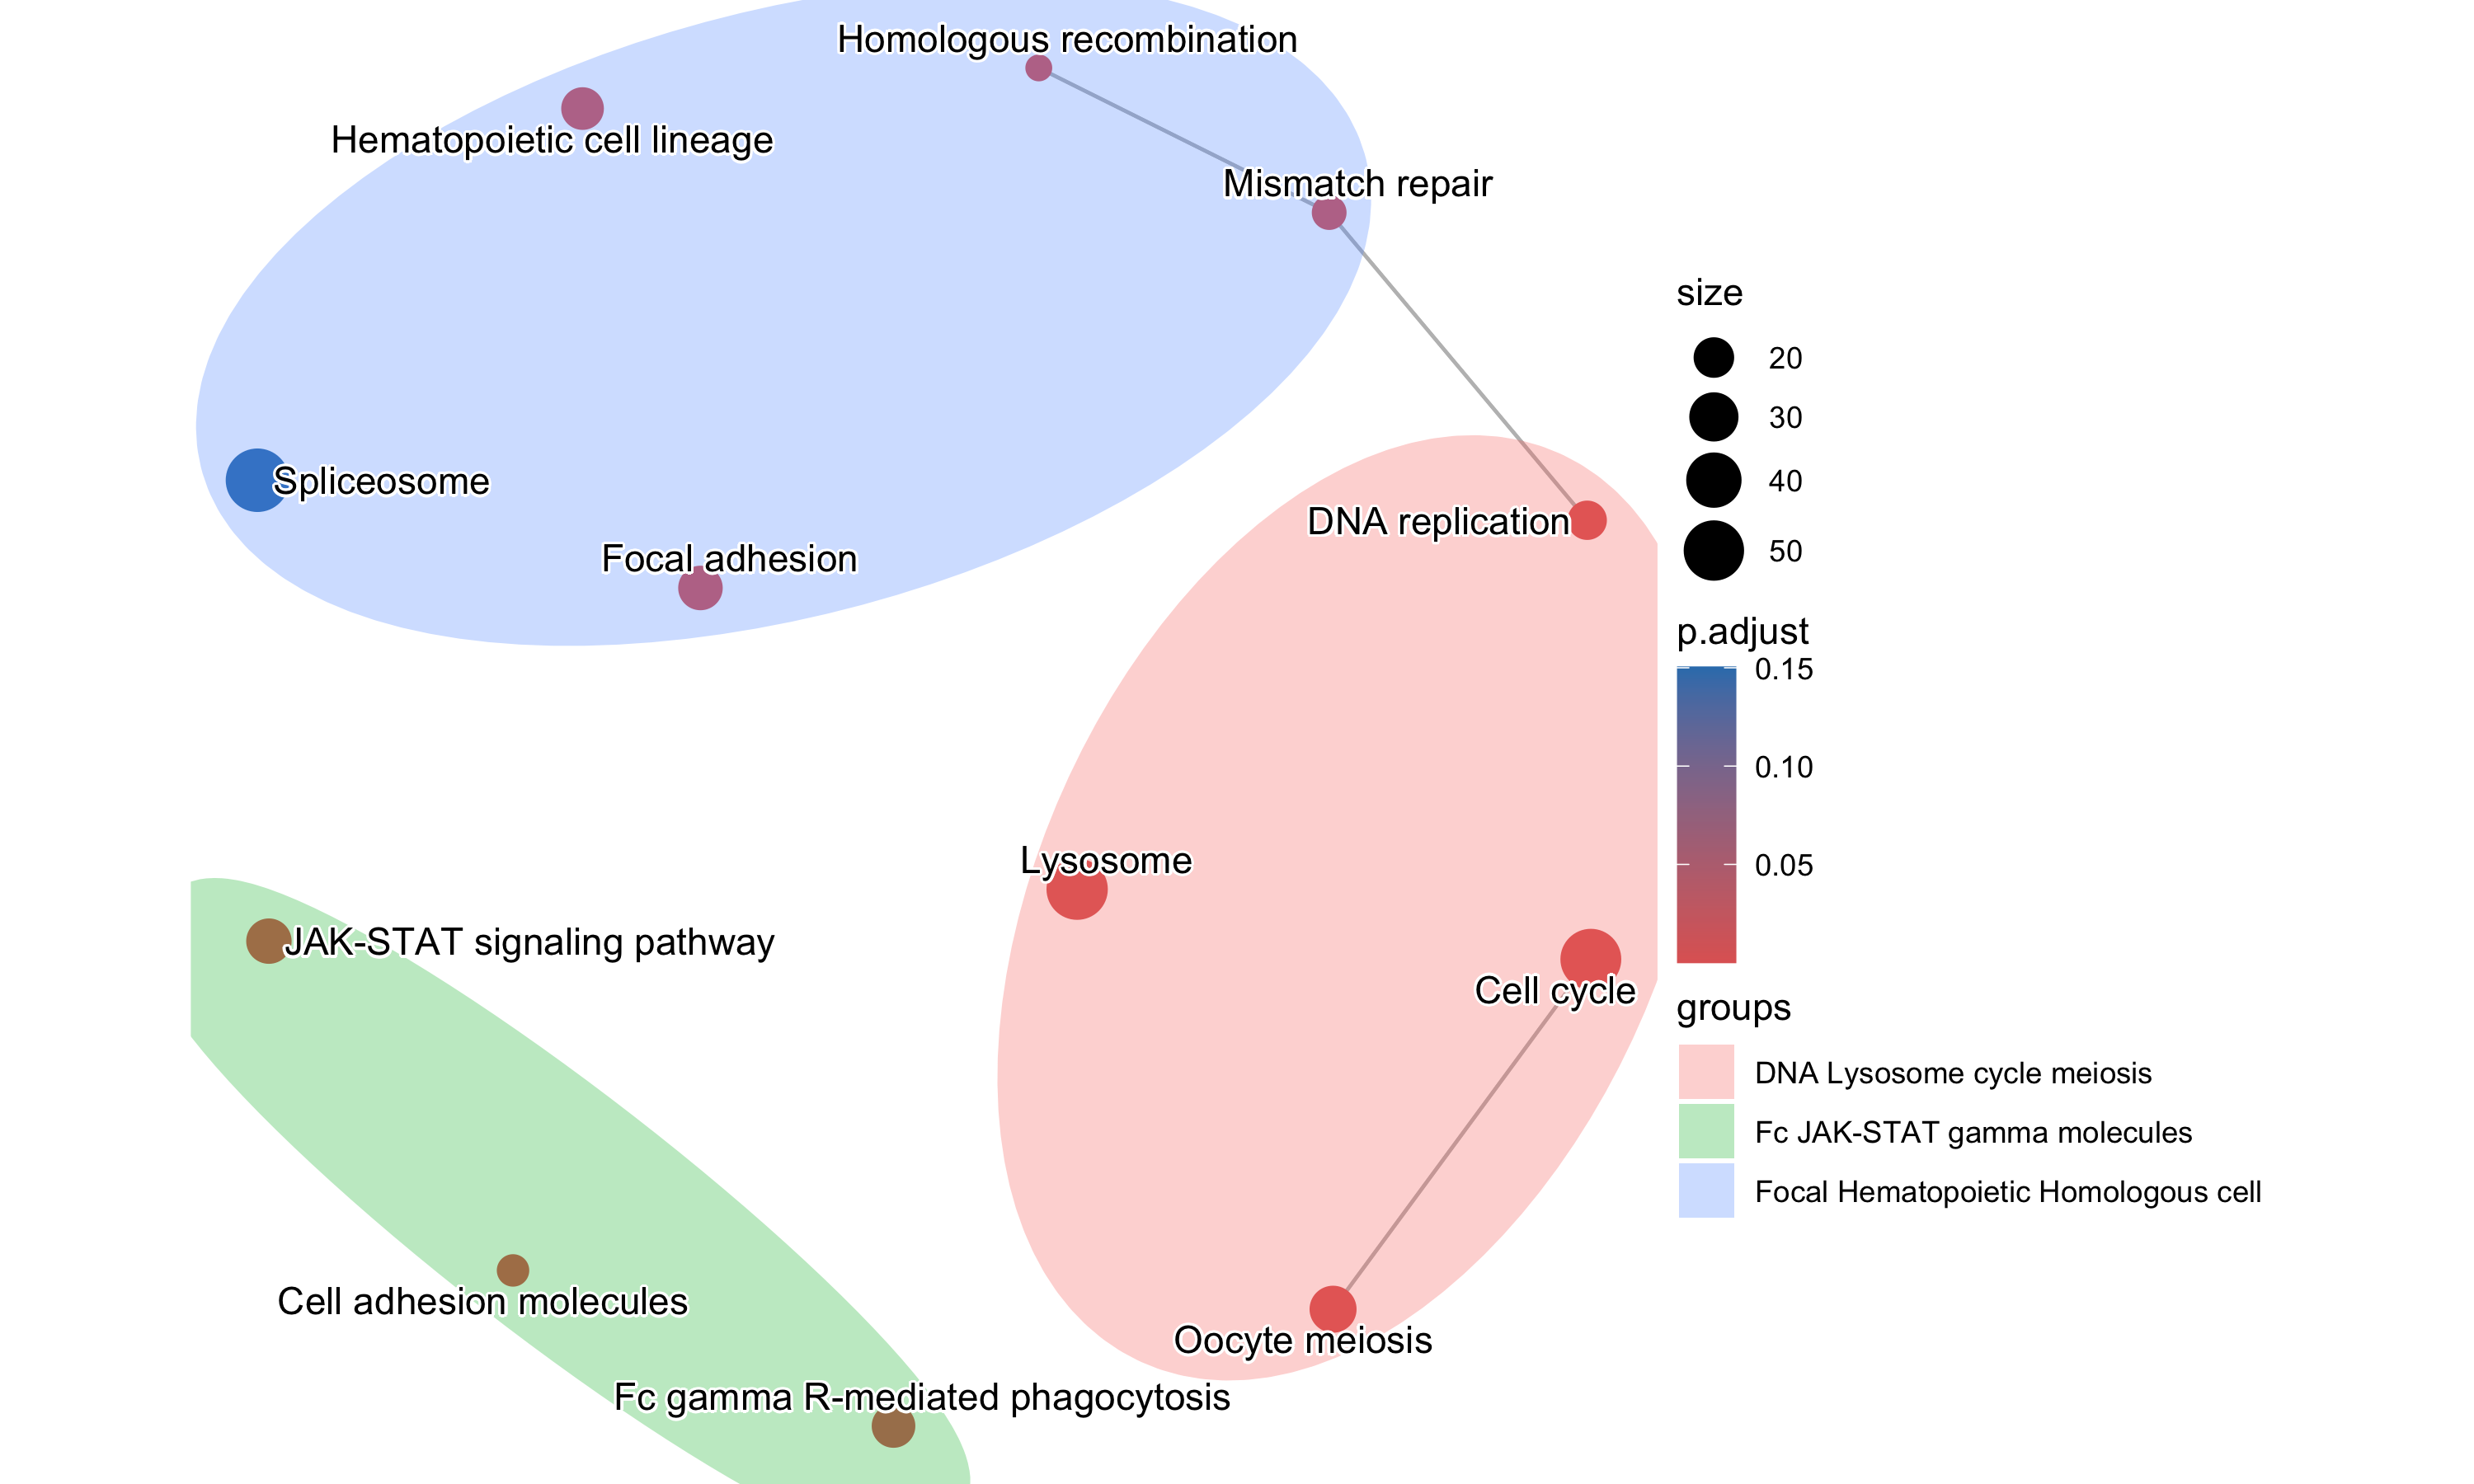

In [278]:
x2 = pairwise_termsim(kk2)
# Example without cluster.params and layout.params
xc <- emapplot(x2, showCategory = selected_pathways, group=TRUE) #node_label

# Print the plot
print(xc)

In [279]:
fig_save(xc , filename = ("figs_paper/emapplot_2025"), formats = c("pdf", "png"), width =20, height =20, units = "cm", dpi = 320)

In [292]:
# xc <- emapplot(
#     x2,
#     showCategory = selected_pathways, layout = "gem",group=TRUE)
# xc

Picking joint bandwidth of 0.116



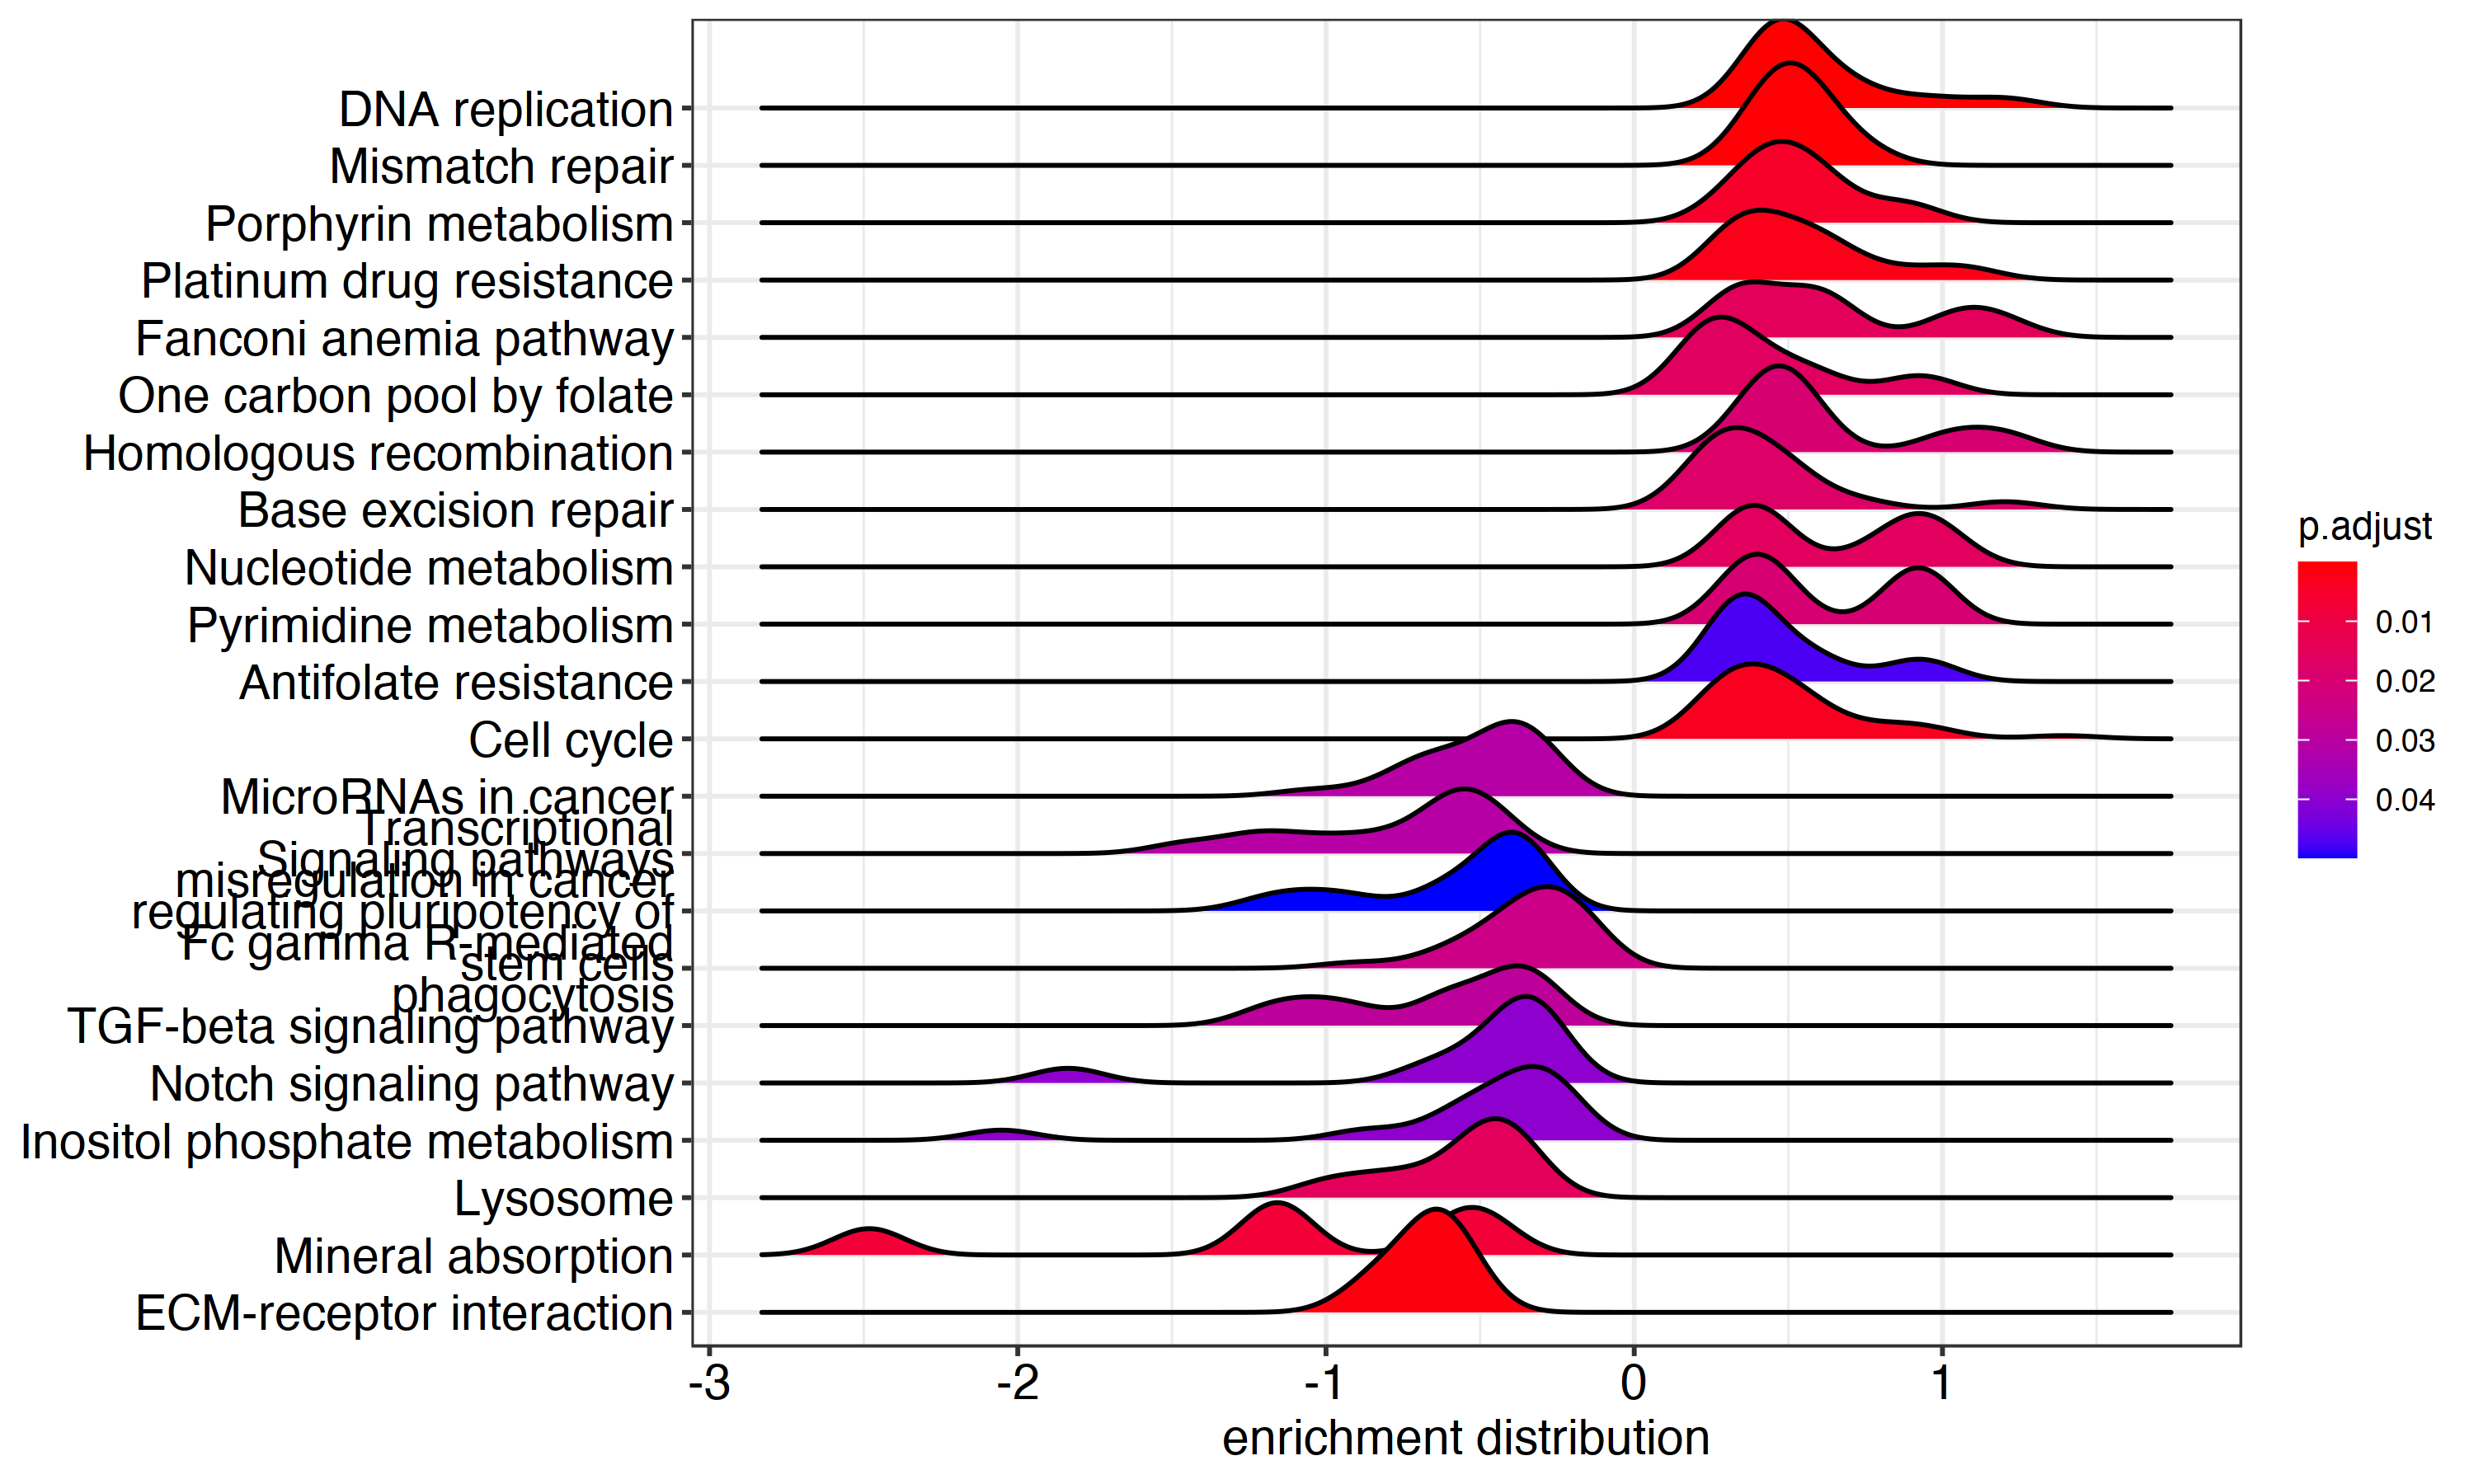

In [69]:
ridgeplot(kk2) + labs(x = "enrichment distribution")

In [70]:
library("DEGreport")

## Another plotting for DE

In [7]:
results(dds)

log2 fold change (MLE): condition2 
LRT p-value: '~ batch + condition' vs '~ 1' 
DataFrame with 7026 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat       pvalue
          <numeric>      <numeric> <logical> <numeric>    <numeric>
NOC2L     0.2270913     -0.0733157        NA   9.50315  4.11524e-13
ISG15     0.0829845     -0.0886571        NA  13.35317  3.11665e-19
SDF4      0.2956741      0.7077189        NA  12.68068  3.70697e-18
UBE2J2    0.2598884      0.0431379        NA  10.69573  5.36221e-15
INTS11    0.2711895     -0.0370490        NA   6.14246  6.68334e-08
...             ...            ...       ...       ...          ...
TUG1      0.0916119       0.177524        NA   7.70805  2.64154e-10
MRTFA     0.1776842       0.637385        NA  13.43613  2.29563e-19
LINC01278 0.0578575       0.762119        NA  11.99861  4.54510e-17
SEPTIN6   1.0435942      -0.306244        NA  75.04192 5.18189e-116
PRKY      0.0637506      -1.542756        NA  11.11566  1.15559e

In [9]:
# Set thresholds
padj_cutoff <- 0.05

# Subset the significant results
sig_res <- filter(DE_scSHM, padj < padj_cutoff) %>%
        dplyr::arrange(padj)

# Check significant genes output
head(sig_res)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
DNER,0.1386676,-0.22631975,NA,418.0380,0,0
MTRNR2L12,1.2900551,0.20980774,NA,1489.5356,0,0
DUSP1,0.5069365,0.39375703,NA,256.3425,0,0
GMDS,0.3586152,-0.62927631,NA,303.4613,0,0
HLA-C,11.7543740,0.04704688,NA,259.5537,0,0
HLA-DQB1,4.0674597,0.07804472,NA,335.8776,0,0


In [15]:
ei <- d %>% rownames_to_column(var="samplename") %>% mutate(samplename = str_replace(samplename,"-",".")) 

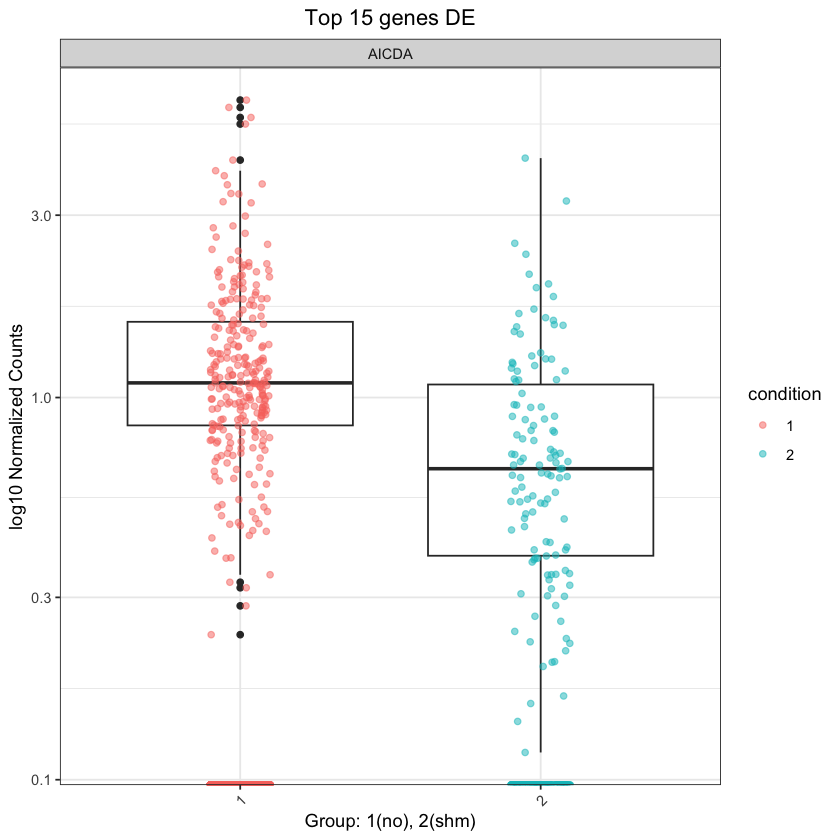

In [28]:
## ggplot of top genes
normalized_counts <- counts(dds, 
                            normalized = TRUE)

# Order results by padj values
top20_sig_genes <- sig_res %>%
        dplyr::arrange(padj) %>%
        dplyr::pull(rowname) %>%
        head(n=15)

#top20_sig_genes <- c("JUND",'LAPTM5','CD74','IL32','RNF213','TSC22D3','PEBP1','FTL','CD79A','IRF1','HLA-DRB1')

top20_sig_genes <- c("AICDA")


top20_sig_norm <- data.frame(normalized_counts) %>%
        rownames_to_column(var = "gene") %>%
        dplyr::filter(gene %in% top20_sig_genes)

gathered_top20_sig <- top20_sig_norm %>%
        gather(colnames(top20_sig_norm)[2:length(colnames(top20_sig_norm))], key = "samplename", value = "normalized_counts")
        
gathered_top20_sig <- inner_join(ei[, c("samplename", "condition" )], gathered_top20_sig, by = c("samplename"))

## plot using ggplot2
sii <- ggplot(gathered_top20_sig) +
     geom_boxplot(aes(x=condition, y=normalized_counts)) +
        geom_point(aes(x = condition, 
                       y = normalized_counts, 
                       color = condition), 
                   position=position_jitter(w=0.1,h=0), alpha=.5) +
        scale_y_log10() +
        xlab("Group: 1(no), 2(shm)") +
        ylab("log10 Normalized Counts") +
        ggtitle("Top 15 genes DE") +
        theme_bw() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        theme(plot.title = element_text(hjust = 0.5)) +
facet_grid(.~gene)

sii

In [29]:
top20_sig_genes

[1] "AICDA"

In [30]:
fig_save(sii , filename = ("figs_paper/top15_DEgenes"), formats = c("pdf", "png"), width = 25, height =15, units = "cm", dpi = 320)

In [31]:
ei <- ei %>% mutate(samplename = str_replace(samplename,"-","."))

In [36]:
head(gathered_top20_sig,30)

,samplename,condition,gene,normalized_counts
,<chr>,<fct>,<chr>,<dbl>
1,AGCTTGACAATGGACG.1_1,2,AICDA,0.0000000
2,CTAGCCTCAATCACAC.1_1,2,AICDA,0.0000000
3,CGAGCACAGGTTCCTA.1_1,2,AICDA,0.6522107
4,ATCATGGGTGGTCTCG.1_1,2,AICDA,0.0000000
5,TCTTTCCGTCTAGTCA.1_1,2,AICDA,0.0000000
6,ACGCCAGAGGCATTGG.1_1,2,AICDA,0.0000000
7,CACATAGTCATACGGT.1_1,2,AICDA,0.6174727
8,TGTGGTAAGGCGACAT.1_1,2,AICDA,0.0000000
9,CAAGTTGCAGCTGTGC.1_1,2,AICDA,0.0000000


#### check expression CTSB in differents chips

In [35]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% #filter(gene == "CTSB", subject == "4")
group_by(condition,gene) %>% summarize(mean_by_gene = mean(normalized_counts)) #%>% filter(gene %like% "CTSB")

`summarise()` has grouped output by 'condition'. You can override using the `.groups` argument.


condition,gene,mean_by_gene
<fct>,<chr>,<dbl>
1,AICDA,0.09803076
2,AICDA,0.27299591


In [120]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% filter(chip == "2") %>% pull(samplename) %>%
                                                                                                           unique() #filter(samplename %like% "GAGCAGACAGGGATTG") #filter(group == "2",gene == "CTSB")

[1] "GAGGTGACAGTATGCT.1_2" "TACCTATAGCGATCCC.1_2" "CAGTAACCATATGGTC.1_2"
 [4] "GGAAAGCCAAGTCTGT.1_2" "ATTGGACCACACCGCA.1_2" "TGAGCATGTTCCATGA.1_2"
 [7] "CGCGGTATCAGGCAAG.1_2" "TAAGAGATCAAACCGT.1_2" "GATCGTATCCCATTTA.1_2"
[10] "AACTCCCAGCGATATA.1_2" "CGAGAAGCAGGAACGT.1_2" "TGAGAGGAGTGAAGTT.1_2"
[13] "AAACCTGTCTTTAGTC.1_2" "AAAGTAGGTCCTCTTG.1_2" "AAGGTTCAGGAACTGC.1_2"
[16] "AGAGTGGGTACTTCTT.1_2" "CAACTAGAGGGTCGAT.1_2" "CAACTAGTCAAAGACA.1_2"
[19] "CAGAATCGTTCAACCA.1_2" "CCACCTATCAACGGGA.1_2" "CCTTCCCAGTGTGAAT.1_2"
[22] "CGAACATCAAGACGTG.1_2" "CGATTGACAGGCAGTA.1_2" "CGGACACTCTCTTATG.1_2"
[25] "CTAATGGAGTCGCCGT.1_2" "CTACCCAGTGGCGAAT.1_2" "CTCAGAAGTGTAAGTA.1_2"
[28] "CTCTGGTCACACGCTG.1_2" "GACGTTACACGTAAGG.1_2" "GAGCAGACAATAGAGT.1_2"
[31] "GATGAGGGTTCGGGCT.1_2" "GCATGCGGTCGACTAT.1_2" "GCGCAGTAGCTAAGAT.1_2"
[34] "GCTGCTTGTGGGTATG.1_2" "TAAACCGAGACTTTCG.1_2" "TAAACCGGTACAGCAG.1_2"
[37] "TACGGGCAGCACACAG.1_2" "TACTTACAGTCTCCTC.1_2" "TATCTCACAACTGGCC.1_2"
[40] "TCAGATGTCAAACCAC.1_2" "TCAGCAAAGAGCTGGT.1_2" "TCAGGATAGTGGACGT.1_2"
[43] "TGAGCCGTCTCGTATT.1_2" "TGCGTGGGTGCATCTA.1_2" "TGCGTGGTCAACCATG.1_2"
[46] "TGGACGCGTAGGGACT.1_2" "CGGAGTCCACTCGACG.1_2" "CAAGATCTCAATCACG.1_2"
[49] "TGTGTTTAGACTGGGT.1_2" "CACCACTAGCCTCGTG.1_2" "GGCTGGTTCCCACTTG.1_2"
[52] "AAACGGGCACGGTAGA.1_2" "AGCTCCTCATGCAACT.1_2" "TCCCGATCAATGGAAT.1_2"
[55] "CTAATGGTCATTGCCC.1_2"

In [8]:
gathered_top20_sig %>% filter(condition == "2",gene == "AICDA")

ERROR: Error in filter(., condition == "2", gene == "AICDA"): object 'gathered_top20_sig' not found


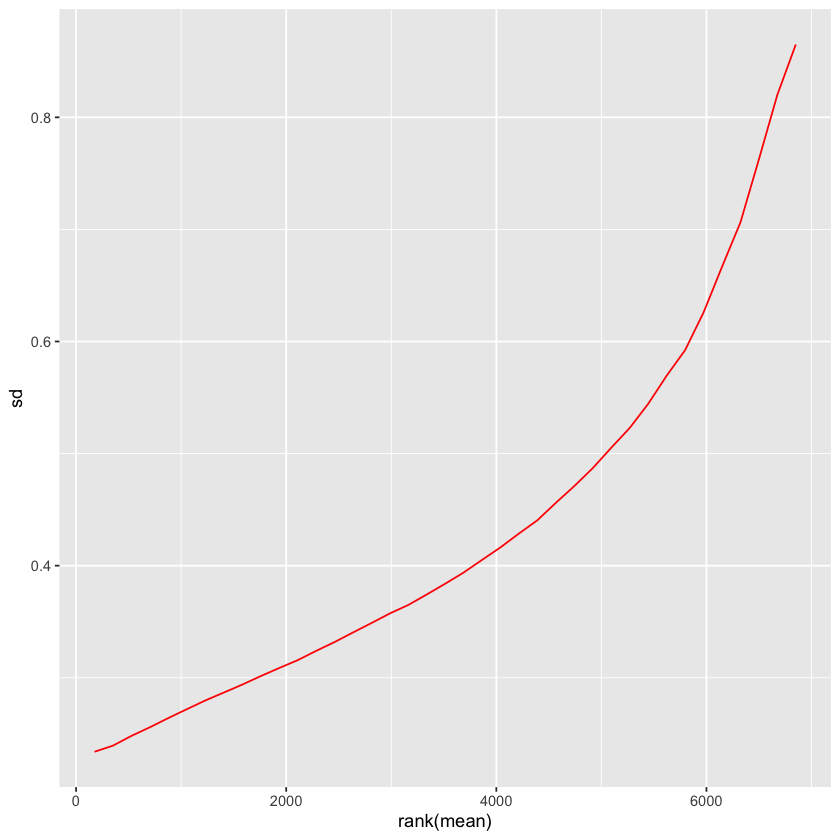

In [122]:
# this gives log2(n + 1)
ntd <- normTransform(dds)
library("vsn")
meanSdPlot(assay(ntd))

In [123]:
colData(dds)

DataFrame with 4052 rows and 4 columns
                        batch condition  cluster sizeFactor
                     <factor>  <factor> <factor>  <numeric>
AGCTTGACAATGGACG-1_1      K1B         2        2   1.155350
CTAGCCTCAATCACAC-1_1      K1B         2        2   0.777052
CGAGCACAGGTTCCTA-1_1      K1B         2        2   3.066494
ATCATGGGTGGTCTCG-1_1      K1B         2        2   1.251420
TCTTTCCGTCTAGTCA-1_1      K1B         2        2   1.362156
...                       ...       ...      ...        ...
ACATACGGTCCAGTTA-1_8      K8B         1        1   1.131128
GCAGCCACATCACGTA-1_8      K8B         1        1   1.051387
GAACCTATCAGATAAG-1_8      K8B         1        1   0.867889
AGTTGGTGTGCAGTAG-1_8      K8B         1        1   2.241964
ACTTGTTGTCTTTCAT-1_8      K8B         1        1   1.136211

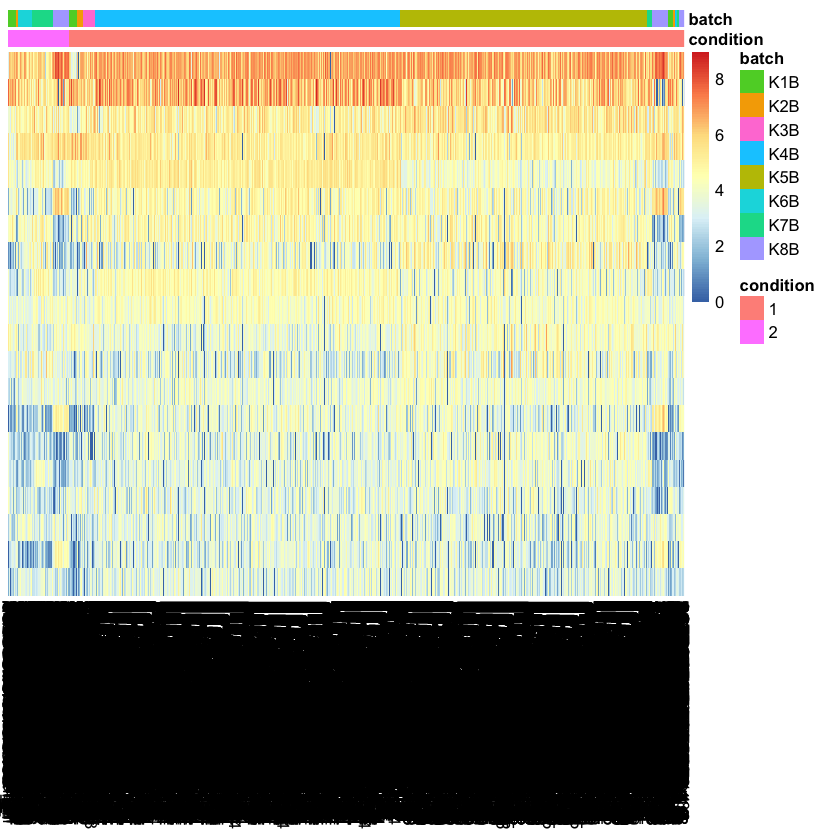

In [124]:
library("pheatmap")
select <- order(rowMeans(counts(dds,normalized=TRUE)),
                decreasing=TRUE)[1:20]
df <- as.data.frame(colData(dds)[,c("condition","batch")])
pheatmap(assay(ntd)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE, annotation_col=df)

In [ ]:
vsd <- vst(dds, blind=FALSE, nsub=48)
rld <- rlog(dds, blind=FALSE)
head(assay(vsd), 3)

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation



In [ ]:
sum( rowMeans( counts(dds, normalized=TRUE)) > 5 )

In [126]:
nrow(dds)

[1] 6604

### K6

In [12]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K6") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      # filter( !geneName %like% "^RPL",
      #         !geneName %like% "^RPS",
      #        dds <- DEgenes(FL.integrated, cells1, cells2)
      # !geneName %like% "^IG[HKL][LVMCG]",
      #          !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k6 <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing



ERROR: Error in rowAnys(x, rows, cols, value = NA, ..., useNames = useNames): Argument 'useNames' must be either TRUE or FALSE


### K7

In [ ]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K7") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
     cts <-
       cts %>% 
       # filter( !geneName %like% "^RPL",
       #         !geneName %like% "^RPS",
       #         !geneName %like% "^IG[HKL][LVMCG]",
       #         !geneName %like% "^MT-" ) %>% 
       column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k7 <- DEgenes(FL.integrated, cells1, cells2)

### K8

In [ ]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K8") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      # filter( !geneName %like% "^RPL",
      #         !geneName %like% "^RPS",
      #         !geneName %like% "^IG[HKL][LVMCG]",
      #         !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k8 <- DEgenes(FL.integrated, cells1, cells2)